## Video: Modern CNN Architectures Part 1 VGG and ResNet

The following is a recording on this topic, I hope you find it useful!  

Feel free to watch at 1.5x or 2x speed.

**Note**: If you find something missing or incorrect in the recording, then please let me know! 

<video id="myVideo" width="750" height="500" controls="controls" preload="none">
  <source src="video-1.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

<script>
    document.getElementById('myVideo').addEventListener('loadedmetadata', function() {
        this.playbackRate = 1.5;
    });
</script>

## Video: Modern CNN Architectures Part 2 DenseNet, MobileNet and Transfer Learning

The following is a recording on this topic, I hope you find it useful!  

Feel free to watch at 1.5x or 2x speed.

**Note**: If you find something missing or incorrect in the recording, then please let me know! 

<video id="myVideo" width="750" height="500" controls="controls" preload="none">
  <source src="video-2.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

<script>
    document.getElementById('myVideo').addEventListener('loadedmetadata', function() {
        this.playbackRate = 1.5;
    });
</script>

## Video: Transfer Learning 

The following is a recording on this topic, I hope you find it useful!  

Feel free to watch at 1.5x or 2x speed.

**Note**: If you find something missing or incorrect in the recording, then please let me know! 

<video id="myVideo" width="750" height="500" controls="controls" preload="none">
  <source src="video-3.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

<script>
    document.getElementById('myVideo').addEventListener('loadedmetadata', function() {
        this.playbackRate = 1.5;
    });
</script>

# CNN Fundamentals

Most of you have seen CNNs before, but we will quickly align on the core ideas so everyone is on the same page.

- **Convolution = local pattern detector**: a small filter slides across the image and computes a dot product at each position.
- **Weight sharing**: the same filter is reused everywhere, which reduces parameters and builds translational consistency.
- **One filter produces one feature map**; multiple filters produce a stack of channels.
- **Nonlinearity + pooling/stride** builds hierarchical features (edges -> textures -> parts -> objects).
- **Translation equivariance**: shifting the input shifts the feature map (pooling adds some invariance).

## Convolution Intuition: 

**Sliding Dot Product**

Below is a toy example of a filter scanning the input. The highlighted input patch produces the highlighted output cell.

In [ ]:
import os
import shutil

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import imageio.v2 as imageio


def draw_grid(ax, data, title="", highlight=None, cmap="RdBu_r", vmin=-10, vmax=10):
    if vmin is None or vmax is None:
        max_abs = np.max(np.abs(data))
        if max_abs == 0:
            max_abs = 1
        if vmin is None:
            vmin = -max_abs
        if vmax is None:
            vmax = max_abs

    ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10, pad=4)

    ax.set_xticks(np.arange(-0.5, data.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, data.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=1)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.issubdtype(data.dtype, np.integer) or np.isclose(val, np.round(val)):
                label = str(int(np.round(val)))
            else:
                label = f"{val:.2f}".rstrip("0").rstrip(".")
            ax.text(j, i, label, ha="center", va="center", fontsize=12)

    if highlight is not None:
        r, c, h, w, color = highlight
        rect = Rectangle((c - 0.5, r - 0.5), w, h, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)


def conv2d_single(x, k):
    kh, kw = k.shape
    oh = x.shape[0] - kh + 1
    ow = x.shape[1] - kw + 1
    out = np.zeros((oh, ow), dtype=int)
    for r in range(oh):
        for c in range(ow):
            out[r, c] = np.sum(x[r:r + kh, c:c + kw] * k)
    return out



In [ ]:
X = np.array(
    [
        [0, 1, 0, 2, 0],
        [2, 0, 1, 0, -1],
        [0, 1, 2, 1, 0],
        [1, 3, 0, 2, 5],
        [0, 2, 1, 0, 1],
    ]
)

K = np.array(
    [
        [1, 0, -1],
        [1, 0, -1],
        [1, 0, -1],
    ]
)

Y = conv2d_single(X, K)


out_dir = "cnn_frames"
os.makedirs(out_dir, exist_ok=True)

frames = []

H, W = X.shape
kh, kw = K.shape
out_h = H - kh + 1
out_w = W - kw + 1

# precompute full output
Y_full = conv2d_single(X, K)

for r in range(out_h):
    for c in range(out_w):
        # partial output up to current position (for visual build-up)
        Y_partial = np.full_like(Y_full, fill_value=0)
        for rr in range(r + 1):
            for cc in range(out_w):
                if rr < r or cc <= c:
                    Y_partial[rr, cc] = Y_full[rr, cc]

        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        fig.subplots_adjust(wspace=0.4)

        draw_grid(axes[0], X, "Input", highlight=(r, c, kh, kw, "blue"))
        draw_grid(axes[1], K, "Kernel", cmap="RdBu_r")
        draw_grid(axes[2], Y_partial, "Output (building)", highlight=(r, c, 1, 1, "red"))

        fig.canvas.draw()
        frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
        frames.append(frame)

        frame_path = os.path.join(out_dir, f"frame_{r:02d}_{c:02d}.png")
        imageio.imwrite(frame_path, frame)

        plt.close(fig)

# Save GIF
imageio.mimsave("./img/cnn_slide.gif", frames, fps=0.5, )

# Optional: save MP4 (requires ffmpeg)
# with imageio.get_writer("cnn_slide.mp4", format="mp4") as writer:
#     for frame in frames:
#         writer.append_data(frame)

# Remove all frames
shutil.rmtree(out_dir)

![](./img/cnn_slide.gif)

## Definition of a Convolutional Layer

For a single‑channel input and a single $K\times K$ filter, the convolution output is:

$$
Y_{i,j} = \sum_{m=1}^{K}\sum_{n=1}^{K} X_{i+m-1,\,j+n-1}\,W_{m,n} + b
$$

- **Learned parameters**: filter weights $W_{m,n}$ and bias $b$.
- Typically there is **one bias per output channel** (one bias per filter).

### Small matrix example

Let the input patch and filter be:

$$
X_{\text{patch}}=
\begin{bmatrix}
1 & 0 & 2 \\
-1 & 3 & 1 \\
0 & 2 & -2
\end{bmatrix},\quad
W=
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix},\quad b=2
$$

Then the output at that location is:

$$
\begin{aligned}
Y &= \langle X_{\text{patch}}, W \rangle + b \\
&= (1\cdot1+0\cdot0+2\cdot(-1)+\dots+(-2)\cdot(-1)) + 2 \\
&= -1
\end{aligned}
$$

### Multi‑channel (for completeness)

For $C$ input channels and $F$ filters:

$$
Y_{i,j,f} = \sum_{c=1}^{C}\sum_{m=1}^{K}\sum_{n=1}^{K} X_{i+m-1,\,j+n-1,\,c}\,W_{m,n,c,f} + b_f
$$

- **Learned parameters**: $W_{m,n,c,f}$ and $b_f$.

## Feature Maps and Channels

- A single filter produces a **single feature map**.
- Each filter has a kernel for every input channel.
- Multiple filters produce a **stack of feature maps** (output channels).
- In practice, filters learn to detect different patterns (vertical edges, corners, textures).
- Each filter has a bias term.

Below: one input channel, two different filters, two different feature maps.

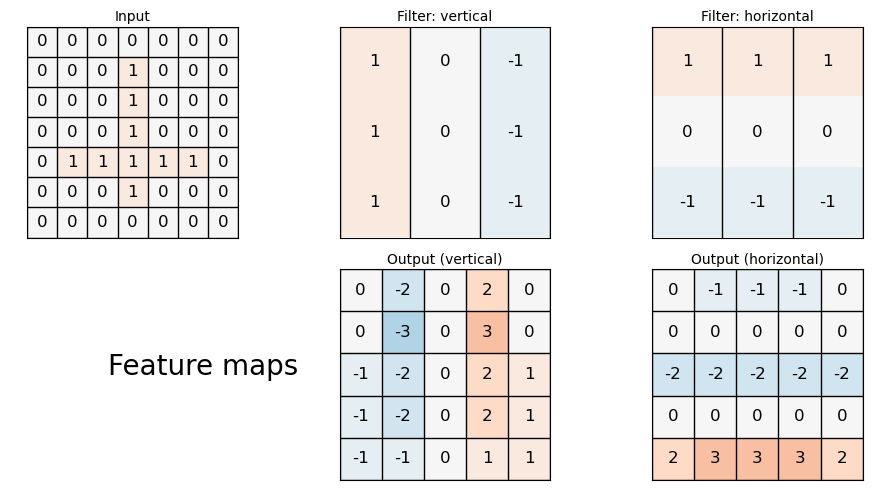

In [19]:
X = np.zeros((7, 7), dtype=int)
X[1:6, 3] = 1  # vertical line
X[4, 1:6] = 1  # horizontal line

K_vert = np.array(
    [
        [1, 0, -1],
        [1, 0, -1],
        [1, 0, -1],
    ]
)
K_horiz = np.array(
    [
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1],
    ]
)

Y_vert = conv2d_single(X, K_vert)
Y_horiz = conv2d_single(X, K_horiz)

fig, axes = plt.subplots(2, 3, figsize=(9, 5))

draw_grid(axes[0, 0], X, "Input")
draw_grid(axes[0, 1], K_vert, "Filter: vertical", cmap="RdBu_r", vmin=-10, vmax=10)
draw_grid(axes[0, 2], K_horiz, "Filter: horizontal", cmap="RdBu_r", vmin=-10, vmax=10)

axes[1, 0].axis("off")
axes[1, 0].text(0.4, 0.5, "Feature maps", fontsize=20)

draw_grid(axes[1, 1], Y_vert, "Output (vertical)")
draw_grid(axes[1, 2], Y_horiz, "Output (horizontal)")

plt.tight_layout()
plt.show()

- In a typical RGB image, there are 3 input channels (R, G, B).
- Therefore the first layer will have filters with 3 kernels.
- Later in the network there may be many channels (e.g. 64, 128, 256, etc.)

![](./img/cnn-multi-channel-cnn.png)

# CNN Building Blocks Components

- **Convolution** (learned filters) is the core feature extractor.
- **Activation** (ReLU, GELU) adds nonlinearity so the model can learn complex patterns.
- **Pooling / stride** controls spatial resolution and invariance.
- **Normalization** (BatchNorm, LayerNorm) stabilizes training.
- **Residual connections** ease optimization in deep networks.
- **Padding** controls the spatial size of the output.


## Activations

Activations introduce nonlinearity so a stack of convolutions can model complex, non‑linear patterns.

- **ReLU** is the default in most CNNs due to simplicity and good gradient flow:

$$
\mathrm{ReLU}(x)=\max(0, x)
$$

- **Leaky ReLU** keeps a small slope for negative values to avoid “dead” neurons:

$$
\mathrm{LeakyReLU}(x)=\max(\alpha x, x)
$$

- **GELU** is smoother and can perform well in deeper networks:

$$
\mathrm{GELU}(x)=x\,\Phi(x)
$$

Practical notes:
- Saturating activations (sigmoid/tanh) can cause vanishing gradients in deep CNNs.
- ReLU‑family activations usually work best for convolutional feature extractors.


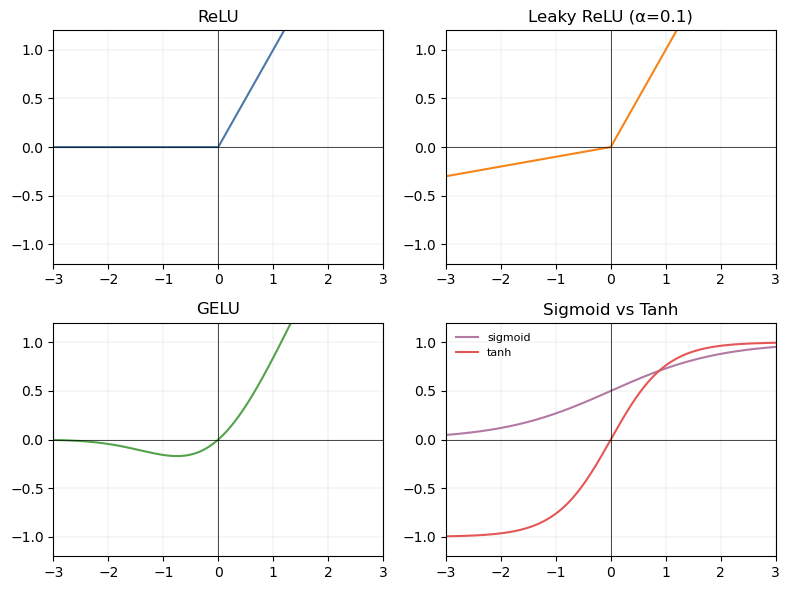

In [14]:
from scipy.special import erf

# Activation function shapes
x = np.linspace(-3, 3, 400)

relu = np.maximum(0, x)
leaky_relu = np.maximum(0.1 * x, x)
gelu = 0.5 * x * (1 + erf(x / np.sqrt(2)))
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0, 0].plot(x, relu, color="#4c78a8")
axes[0, 0].set_title("ReLU")
axes[0, 0].axhline(0, color="black", linewidth=0.5)
axes[0, 0].axvline(0, color="black", linewidth=0.5)

axes[0, 1].plot(x, leaky_relu, color="#f58518")
axes[0, 1].set_title("Leaky ReLU (α=0.1)")
axes[0, 1].axhline(0, color="black", linewidth=0.5)
axes[0, 1].axvline(0, color="black", linewidth=0.5)

axes[1, 0].plot(x, gelu, color="#54a24b")
axes[1, 0].set_title("GELU")
axes[1, 0].axhline(0, color="black", linewidth=0.5)
axes[1, 0].axvline(0, color="black", linewidth=0.5)

axes[1, 1].plot(x, sigmoid, label="sigmoid", color="#b279a2")
axes[1, 1].plot(x, tanh, label="tanh", color="#e45756")
axes[1, 1].set_title("Sigmoid vs Tanh")
axes[1, 1].legend(frameon=False, fontsize=8)
axes[1, 1].axhline(0, color="black", linewidth=0.5)
axes[1, 1].axvline(0, color="black", linewidth=0.5)

for ax in axes.ravel():
    ax.set_xlim(-3, 3)
    ax.set_ylim(-1.2, 1.2)
    ax.grid(True, linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

## Pooling

Pooling reduces spatial resolution and provides some translation invariance.

- **Max pooling** emphasizes the strongest local response:

$$
Y_{i,j}=\max_{(m,n)\in\mathcal{W}} X_{i+m,\,j+n}
$$

- **Average pooling** keeps a smoother summary of a region.
- Pooling can be replaced by **strided convolution** (learned downsampling).

Trade‑offs:

- Too much pooling can remove fine details needed for localization (e.g., segmentation).
- For classification, moderate downsampling improves robustness and reduces compute.

In [15]:
# Pooling visualization as GIF (same grid style)

X_pool = np.array(
    [
        [1, 1, -8, 0],
        [-4, 6, 0, -4],
        [0, 1, 5, 2],
        [-1, 0, -3, 0],
    ]
)

pool_h, pool_w = 2, 2
stride = 2

H, W = X_pool.shape
out_h = (H - pool_h) // stride + 1
out_w = (W - pool_w) // stride + 1

# Precompute outputs
max_pool = np.zeros((out_h, out_w))
avg_pool = np.zeros((out_h, out_w))

for r in range(out_h):
    for c in range(out_w):
        rr = r * stride
        cc = c * stride
        window = X_pool[rr:rr + pool_h, cc:cc + pool_w]
        max_pool[r, c] = np.max(window)
        avg_pool[r, c] = np.mean(window)

frames = []

# Animate sliding window
for r in range(out_h):
    for c in range(out_w):
        rr = r * stride
        cc = c * stride

        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        fig.subplots_adjust(wspace=0.4)

        draw_grid(axes[0], X_pool, "Input", highlight=(rr, cc, pool_h, pool_w, "blue"), vmin=-10, vmax=10)
        draw_grid(axes[1], max_pool, "MaxPool 2x2", highlight=(r, c, 1, 1, "red"), vmin=-10, vmax=10)
        draw_grid(axes[2], avg_pool, "AvgPool 2x2", highlight=(r, c, 1, 1, "red"), vmin=-10, vmax=10)

        fig.canvas.draw()
        frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
        frames.append(frame)
        plt.close(fig)

imageio.mimsave("./img/pooling_slide.gif", frames, fps=0.5, loop=0)

![](./img/pooling_slide.gif)

## Strided Convolution

Strided convolution downsamples by **skipping positions** in the sliding window, which reduces spatial resolution while still learning weights.

- A stride of $S=2$ moves the kernel two pixels at a time in both directions.
- This reduces output size and computation, but can discard fine detail.

For a 2D convolution with stride $S$ and no padding:

$$
Y_{i,j} = \sum_{m=1}^{K}\sum_{n=1}^{K} X_{i\cdot S + m - 1,\, j\cdot S + n - 1}\, K_{m,n}
$$

Below is an animated example of **stride = 2**. Each step highlights the input window and the corresponding output cell.

In [17]:
# Strided convolution animation (stride=2)
import imageio.v2 as imageio

X_stride = np.array(
    [
        [1, 0, 2, -1, 3],
        [2, -2, 1, 0, -1],
        [0, 3, -1, 2, 1],
        [-1, 1, 0, -2, 2],
        [2, 0, 1, -1, 0],
    ]
)

K_stride = np.array(
    [
        [1, 0, -1],
        [1, 0, -1],
        [1, 0, -1],
    ]
)

stride = 2
kh, kw = K_stride.shape
H, W = X_stride.shape
out_h = (H - kh) // stride + 1
out_w = (W - kw) // stride + 1

# Precompute strided output
Y_stride = np.zeros((out_h, out_w))
for r in range(out_h):
    for c in range(out_w):
        rr = r * stride
        cc = c * stride
        window = X_stride[rr:rr + kh, cc:cc + kw]
        Y_stride[r, c] = np.sum(window * K_stride)

frames = []

for r in range(out_h):
    for c in range(out_w):
        rr = r * stride
        cc = c * stride

        # Partial output to show progression
        Y_partial = np.zeros_like(Y_stride)
        for rr_out in range(r + 1):
            for cc_out in range(out_w):
                if rr_out < r or cc_out <= c:
                    Y_partial[rr_out, cc_out] = Y_stride[rr_out, cc_out]

        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        fig.subplots_adjust(wspace=0.4)

        draw_grid(axes[0], X_stride, f"Input (stride={stride})", highlight=(rr, cc, kh, kw, "blue"), vmin=-6, vmax=6)
        draw_grid(axes[1], K_stride, "Kernel", vmin=-6, vmax=6)
        draw_grid(axes[2], Y_partial, "Output (building)", highlight=(r, c, 1, 1, "red"), vmin=-6, vmax=6)

        fig.canvas.draw()
        frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
        frames.append(frame)
        plt.close(fig)

imageio.mimsave("./img/strided_conv_slide.gif", frames, fps=0.5, loop=0)

![](./img/strided_conv_slide.gif)

## Normalization

Normalization stabilizes training by keeping activations well‑scaled.

- **BatchNorm** (most common in CNNs) normalizes channel activations and then re‑scales:

$$
\hat{x}=\frac{x-\mu_B}{\sqrt{\sigma_B^2+\epsilon}},\quad y=\gamma\hat{x}+\beta
$$

- **LayerNorm / GroupNorm** can be preferred when batch sizes are small.

Effects:
- Allows higher learning rates and faster convergence.
- Reduces sensitivity to initialization and scale changes.



## Residual Connections

Residual connections help very deep networks train by letting layers learn a **residual** function.

$$
\mathbf{y}=\mathcal{F}(\mathbf{x})+\mathbf{x}
$$

- If dimensions differ, a **projection** (often a $1\times1$ convolution) aligns shapes.
- Residual paths improve gradient flow and reduce degradation in deep networks.


## Output Size of Convolutions

For a 2D convolution, the output size (per spatial dimension) is:

$$
H_{out}=\left\lfloor\frac{H+2P-K}{S}\right\rfloor+1,\quad
W_{out}=\left\lfloor\frac{W+2P-K}{S}\right\rfloor+1
$$

**Definitions**:
- $H, W$ = input height and width
- $K$ = kernel size (assume square $K\times K$)
- $P$ = padding on each side
- $S$ = stride
- $\lfloor\cdot\rfloor$ = floor (round down)

**Example** (square input):

$$
H=W=32,\; K=3,\; P=1,\; S=2
$$

$$
\begin{aligned}
H_{out}=W_{out}&=\left\lfloor\frac{32+2\cdot1-3}{2}\right\rfloor+1 \\
&=\left\lfloor\frac{31}{2}\right\rfloor+1\\
&=15+1=16
\end{aligned}
$$

The **number of output channels** equals the number of filters $F$ used in the layer.

In [18]:
# X = np.arange(1, 17).reshape(4, 4)
# P = 1
# X_pad = np.pad(X, ((P, P), (P, P)), mode="constant")

# K = 3
# S1 = 1
# S2 = 2
# H, W = X.shape

# H_out_s1 = (H + 2 * P - K) // S1 + 1
# H_out_s2 = (H + 2 * P - K) // S2 + 1

# fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# draw_grid(axes[0], X, "Input 4x4", vmin=-20, vmax=20)
# draw_grid(axes[1], X_pad, "Zero padded (P=1)", vmin=-20, vmax=20)

# plt.tight_layout()
# plt.show()

# print(f"Output size with K=3, S=1, P=1: {H_out_s1} x {H_out_s1}")
# print(f"Output size with K=3, S=2, P=1: {H_out_s2} x {H_out_s2}")

## Pooling vs. Strided Convolution

- Pooling reduces spatial size and can add some translation invariance. 
- Strided convolution can replace pooling by downsampling while still learning the weights.

Below is a small example comparing max pooling with a strided convolution (using a simple 2x2 sum kernel).

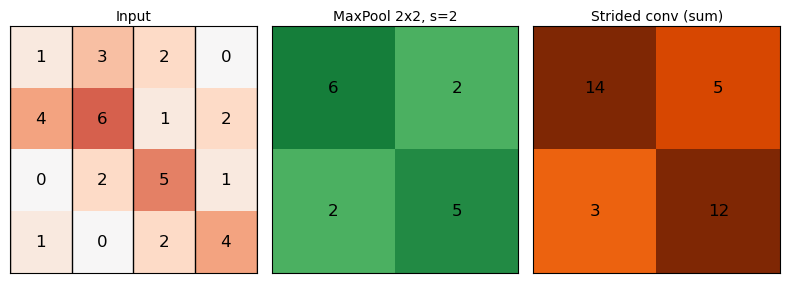

In [43]:
X = np.array(
    [
        [1, 3, 2, 0],
        [4, 6, 1, 2],
        [0, 2, 5, 1],
        [1, 0, 2, 4],
    ]
)

# Max pooling 2x2, stride 2
pool = np.array(
    [
        [np.max(X[0:2, 0:2]), np.max(X[0:2, 2:4])],
        [np.max(X[2:4, 0:2]), np.max(X[2:4, 2:4])],
    ]
)

# Strided convolution 2x2, stride 2 (sum kernel)
K = np.ones((2, 2), dtype=int)
conv_stride = np.array(
    [
        [np.sum(X[0:2, 0:2] * K), np.sum(X[0:2, 2:4] * K)],
        [np.sum(X[2:4, 0:2] * K), np.sum(X[2:4, 2:4] * K)],
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(8, 3))

draw_grid(axes[0], X, "Input")
draw_grid(axes[1], pool, "MaxPool 2x2, s=2", cmap="Greens")
draw_grid(axes[2], conv_stride, "Strided conv (sum)", cmap="Oranges")

plt.tight_layout()
plt.show()

## Receptive Field Growth

- Stacking multiple small kernels (e.g., multiple 3x3 layers) increases the receptive field while keeping parameters manageable. 
    - This is one reason modern CNNs favor many small convolutions instead of one large filter.

**Parameter Count vs. Fully Connected**

- Convolutions reuse parameters across spatial positions, which makes them much more efficient than fully connected layers on images. 
    - The chart below contrasts a small convolutional layer with a fully connected layer on the same input size.

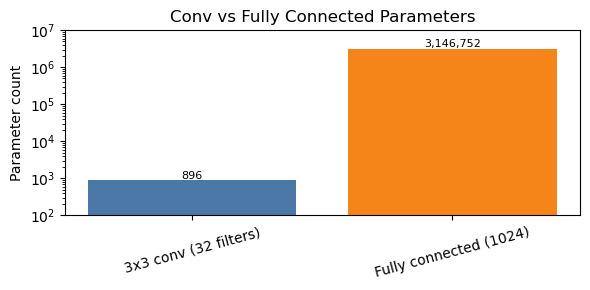

In [57]:
# # Receptive field visualization
# fig, ax = plt.subplots(figsize=(4, 4))
# center = 5
# sizes = [1, 3, 5, 7]
# colors_list = ["#cce5ff", "#99ccff", "#66b2ff", "#3399ff"]

# for s, color in zip(sizes, colors_list):
#     ax.add_patch(Rectangle((center - s / 2, center - s / 2), s, s,
#                            fill=False, edgecolor=color, linewidth=2))
#     ax.text(center + s / 2 + 0.2, center, f"{s}x{s}", va="center", fontsize=8)

# ax.set_xlim(0, 10)
# ax.set_ylim(0, 10)
# ax.set_aspect("equal")
# ax.set_title("Receptive Field Growth", fontsize=10)
# ax.axis("off")
# plt.show()

# Parameter count comparison
H, W, C = 32, 32, 3
C_out = 32
K = 3

conv_params = K * K * C * C_out + C_out
fc_params = H * W * C * 1024 + 1024

labels = ["3x3 conv (32 filters)", "Fully connected (1024)"]
values = [conv_params, fc_params]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, values, color=["#4c78a8", "#f58518"])
ax.set_ylabel("Parameter count")
ax.set_title("Conv vs Fully Connected Parameters")
ax.tick_params(axis="x", rotation=15)
ax.set_yscale("log")
ax.set_ylim(1e2, 1e7)

for i, v in enumerate(values):
    ax.text(i, v * 1.1, f"{v:,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# Modern CNN Fundamentals

- Traditional CNNs face vanishing gradient problems as depth increases
- Modern architectures introduce innovations to overcome these limitations:
    - VGG: Introduced modern CNN design principles by emphasizing deep architectures with small convolutional filters
    - ResNet: Uses skip (shortcut) connections to ease gradient flow
    - DenseNet: Enhances feature reuse with dense connectivity
    - MobileNet: Optimized for mobile and embedded systems using depth-wise separable convolutions

# VGG

- [VGG](https://arxiv.org/pdf/1409.1556v6) is a neural network architecture designed for image classification tasks
- Developed by Visual Geometry Group at the University of Oxford
- Demonstrated the effectiveness of deep networks with uniform architecture
- Pioneered the use of small convolutional kernels $(3 \times 3)$ stacked on top of each other
- VGG is a popular choice for transfer learning due to its robustness and feature extraction capabilities
- Influenced the design of subsequent architectures, including ResNet and Inception

![](./img/cnn-kernels-filters.png)

## VGG Architecture

- VGG-16 has 16 layers with learnable parameters, emphasizing depth over width
    - VGG-11 (11 layers), VGG-13 (13 layers) and VGG-19 (19 layers)
- Input size of $(3 \times 224 \times 224)$ RGB images
- **Convolutional Layers:** 13 convolutional layers for feature extraction
    - Small $(3 \times 3)$ kernels, maximizing the number of layers while keeping the number of parameters manageable
- **Max Pooling:** $(2 \times 2)$ max pooling after several convolutional layers to reduce dimensionality
- **Fully Connected Layers:** Flatten final convolutional block then 3 fully connected layers give the final logits
- **Output Layer:** Softmax activation for multi-class classification
- Output size of $(batchsize \times 1000)$ for ImageNet classification

## VGG16 Diagram

![](./img/vgg-16.png)

## VGG Configurations {.nostretch}

[![](./img/vgg-configurations.png){width=50%}](https://arxiv.org/pdf/1409.1556#page=3)

# ResNet

:::: {.columns}
::: {.column width="65%"}

- [ResNet](https://arxiv.org/pdf/1512.03385) introduced residual learning, enabling the training of very deep networks without the vanishing gradients
- Achieved remarkable accuracy on the ImageNet dataset and won the ILSVRC in 2015
- Commonly applied in image classification, object detection, and various computer vision tasks
- Frequently used as a pre-trained model for fine-tuning on specific tasks.
- Effective training of deep networks, improved gradient flow, and a lasting influence on modern architectures
- Capable of very deep networks with over a hundred layers (e.g., ResNet50, ResNet101, ResNet152)

:::

::: {.column width="5%"}
:::

::: {.column width="30%"}
![](./img/residual-block.png){width=90%}
:::
::::

## ResNet Architecture

- **Residual Blocks**, incorporates skip (shortcut) connections that bypass layers to improve gradient flow
- **Batch Normalization**, stabilizes and accelerates training, applied after convolutional layers

- Input size of $(3 \times 224 \times 224)$ RGB images
- Convolutional Layers: Composed of multiple residual blocks
    - Two or three convolutional layers with ReLU activations
    - Batch normalization and skip connections
- Fully Connected Layers
    - Typically includes a global average pooling layer followed by a fully connected layer
- Output Layer: Softmax activation for multi-class classification
- Output size of $(batchsize \times 1000)$ for ImageNet classification

## ResNet vs. VGG Diagram

:::: {.columns}
::: {.column width="60%"}

Key Features

- Solid arrows indicate residual connections
- Dashed arrows represent residual connections with $1 \times 1$ convolutions with stride of 2 for down sampling
- The "**/2**" symbol indicates a stride of 2 (usually for convolutions but also for pooling operations)
    - The "downsampling [is performed] directly by convolutional layers that have a stride of 2"
    - For example "3 x 3 conv, 64 /2" indicates a $3 \times 3$ kernel 64 filters a stride of 2 for example

:::

::: {.column width="5%"}
:::

::: {.column width="35%"}
[![](./img/resenet-diagram.png){width=80%}](https://arxiv.org/pdf/1512.03385#page=4)
:::
::::


## ResNet Configurations {.nostretch}

[![](./img/resnet-configurations.png)](https://arxiv.org/pdf/1512.03385#page=5)

# DenseNet

:::: {.columns}
::: {.column width="55%"}
- [DenseNet](https://arxiv.org/pdf/1608.06993) introduced dense connectivity patterns, where each layer is connected to every other layer in a block
    - facilitates feature reuse and improved information/gradient flow
- Achieves high accuracy with fewer parameters compared to traditional deep networks due to feature reuse
- Demonstrated State-of-the-Art performance on benchmark datasets like ImageNet
:::

::: {.column width=45%}
[![](./img/dense-block.png){width=100%}](https://arxiv.org/pdf/1608.06993)
:::
::::

## DenseNet Architecture {.nostretch}

- **Input:** Standard input size of $(3 \times 224 \times 224)$ RGB images
- **Dense Blocks:** Composed of multiple dense blocks, where each layer receives input from all preceding layers in the block
    - Previous layer outputs are **Concatenated** together instead of added like in the ResNet architecture
- **Growth Rate:** Each layer in a dense block outputs a fixed number of feature maps (growth rate), controlling the increase in the number of channels
- **Transition Layers:** Uses bottleneck layers to reduce the number of input feature maps between dense blocks
- **Output Layer:** Typically includes a global average pooling layer followed by a fully connected layer for classification

[![](./img/densenet-overview-diagram.png){width=90%}](https://arxiv.org/pdf/1608.06993#page=3)

## Dense Block Diagram

![](./img/dense-block-diagram.png)

## DenseNet Configurations {.nostretch}

[![](./img/densenet-configurations.png)](https://arxiv.org/pdf/1608.06993#page=4)

## Torchvision DenseNet {.scrollable}

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torchvision.models import DenseNet121_Weights


class DenseNetCustom(nn.Module):
    def __init__(self, num_classes=1000):
        super(DenseNetCustom, self).__init__()
        # Using a pre-trained DenseNet-121
        self.densenet = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
        # Adjust the classifier to match the number of classes
        self.densenet.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.densenet(x)
        return x


# Example usage
model = DenseNetCustom(num_classes=10)
print(model)

DenseNetCustom(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, mome

# MobileNet 

- [MobileNet](https://arxiv.org/pdf/1704.04861) is an efficient CNN for mobile computer vision applications
- Optimized for **low latency**, **reduced memory usage**, and **smaller model size**  
- Used in image classification, object detection (e.g., SSDLite), and face recognition
- Inspired modern architectures, including **EfficientNet** and mobile-friendly deep learning designs

**Advantages**:

- Low computational cost  
- Efficient for mobile and IoT devices

**Trade-offs**:

- Slightly lower accuracy compared to larger models  
- Requires tuning for latency vs. performance balance  

## MobileNet Architecture

- Standard convolutions are computationally expensive.  
- **Depthwise separable convolutions** split a convolution into:  
  1. **Depthwise convolution** (spatial filtering)
      - Depthwsie convolutions uses thee concepts of groups, which is documented in the [PyTorch documentation](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
  2. **Pointwise convolution** (1x1 for combining channels)  
- **Reduction in computation**: Significantly fewer parameters and FLOPs

- [MobileNet](https://arxiv.org/pdf/1704.04861#page=3) reduces computation case by about 8 or 9 times for a $3 \times 3$ convolution

$$
\begin{align}
cost \ ratio &= \frac{1}{N} + \frac{1}{D^2_k} \\
&= \frac{1}{32} + \frac{1}{3^2}
\end{align}
$$

Where $N$ is the number of output channels and $D_k$ is the kernel size

## Single Group Convolution

![](./img/1-group-convolution.png)

## Two Group Convolution

![](./img/2-group-convolution.png)

## Depthwise Convolution

![](./img/depth-wise-convolution.png)

## Depthwise Seperable Convolution

![](./img/depth-wise-seperable.png)

## MobileNet Configuration

[![](./img/mobilenet-configuration.png)](https://arxiv.org/pdf/1704.04861#page=4)

# Transfer Learning

- **Knowledge Transfer**: Leverages knowledge gained from one task to improve performance on a different but related task
- **Efficiency**: Reduces the need for large amounts of labeled data and extensive computational resources for training
- **Faster Convergence**: Models can converge more quickly when starting from pre-trained weights compared to training from scratch

#### Process Overview:
1. **Pre-training**: A model is trained on a large dataset (e.g., ImageNet) to learn general features
2. **Fine-tuning**: The pre-trained model is adapted to a new task by retraining it on a smaller, task-specific dataset
3. **Layer Freezing**: Often, earlier layers are frozen (not updated) during fine-tuning to retain learned features, while later layers are retrained

## Transfer Learning Approaches

#### Categories:
- **Inductive Transfer Learning**: The source and target tasks are different, but the model is adapted to the target task
- **Transductive Transfer Learning**: The source and target tasks are the same, but the domains differ (e.g., different datasets)
- **Domain Adaptation**: Focuses on adapting a model trained on one domain to work well on a different but related domain

- **Feature extraction**:  
  - Use pre-trained model as a fixed feature extractor  
  - Freeze all layers except the final fully connected layer  
- **Fine-tuning**:  
  - Unfreeze some layers and retrain with a lower learning rate  

## Applications and Advantages of Transfer Learning

#### Applications:
- **Computer Vision**: Fine-tuning models like VGG, ResNet, and MobileNet for specific image classification tasks.
- **Natural Language Processing**: Adapting models like BERT and GPT for sentiment analysis or text classification.
- **Speech Recognition**: Using pre-trained models to improve performance on specific speech tasks.

#### Advantages :
- Faster convergence compared to training from scratch  
- Leverages **learned representations** from large datasets (e.g., ImageNet)  
- Often leads to **better performance with limited data**  

# Transfer Learning Example

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

In [2]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Define CIFAR100 dataset, resize to 224x224 and normalize
transform = transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.Resize((224, 224)), 
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

test_transform = transforms.Compose(
        [
            transforms.Resize((224, 224)), 
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

trainset = torchvision.datasets.CIFAR100(root='/home/ben/data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='/home/ben/data', train=False, download=True, transform=test_transform)

# Define the data loaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# Loop over the data loader and print the first 10 images
for images, labels in trainloader:
    print(images.shape)
    break

torch.Size([64, 3, 224, 224])


In [4]:
# Number of images in the dataset
num_images = len(trainset)
print(f'Number of images in the dataset: {num_images}') 

# Number of batches in the dataloader
num_batches = len(trainloader)
print(f'Number of batches in the dataloader: {num_batches}')


Number of images in the dataset: 50000
Number of batches in the dataloader: 782


In [5]:
# Inspect a single image
image, label = next(iter(trainloader))
print(image.shape)
# Statistical properties
print('min:', image.min())
print('max:', image.max())
print('mean:', image.mean())
print('std:', image.std())
print('labels shape:', label.shape)
print('labels:', label)

torch.Size([64, 3, 224, 224])
min: tensor(-2.1179)
max: tensor(2.6400)
mean: tensor(0.1037)
std: tensor(1.1633)
labels shape: torch.Size([64])
labels: tensor([54, 96, 99, 58, 95, 37, 90, 32, 78, 82, 48, 44, 21, 86, 81, 66, 25, 56,
        40, 15,  6, 47, 13, 94, 30, 14, 28, 98, 75, 11, 80, 54,  4, 94, 95,  7,
        22, 47, 69, 42, 86, 12, 91, 57, 84, 77, 30, 60,  5, 71, 33, 37, 82, 82,
         8, 20, 50, 24, 70, 38, 12,  6, 67, 79])


In [6]:
def unnormalize(tensor, mean, std):
    """
    Un-normalizes a tensor image with mean and standard deviation.
    Args:
        tensor (torch.Tensor): Tensor image of size (C, H, W)
        mean (sequence): Sequence of means for each channel
        std (sequence): Sequence of standard deviations for each channel
    """
    # Method 1: Using mul_ and add_ (in-place operations)
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

    # Method 2: Using the formula (not in-place)
    # tensor = tensor * torch.tensor(std).view(-1, 1, 1) + torch.tensor(mean).view(-1, 1, 1)
    # return tensor

# Example usage for CIFAR-100:
# cifar_mean = [0.5071, 0.4867, 0.4408]
# cifar_std = [0.2675, 0.2565, 0.2761]

cifar_mean = [0.485, 0.456, 0.406]
cifar_std = [0.229, 0.224, 0.225]

# # For a batch of images
# unnormalized_images = unnormalize(images.clone(), cifar_mean, cifar_std)

# For a single image
unnormalized_image = unnormalize(image[0].clone(), cifar_mean, cifar_std)

# inspect the unnormalized image
print(unnormalized_image.shape)
print(unnormalized_image.min())
print(unnormalized_image.max())
print(unnormalized_image.mean())
print(unnormalized_image.std())

torch.Size([3, 224, 224])
tensor(0.)
tensor(0.9412)
tensor(0.4334)
tensor(0.2310)


In [7]:
# Get CIFAR100 class names
class_names = trainset.classes
print(class_names)

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

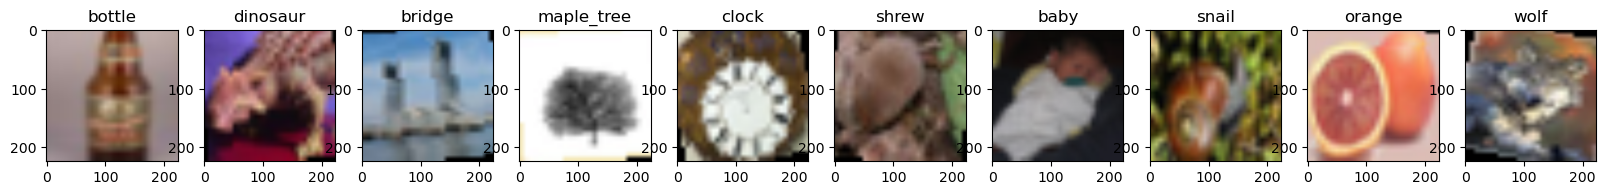

In [8]:
# Define a function to plot the first 10 images
def plot_images(images, labels):
    plt.figure(figsize=(20, 10))
    for i in range(10):
        # add label to the image
        plt.subplot(1, 10, i+1)
        unnormalized_image = unnormalize(images[i], cifar_mean, cifar_std)
        plt.imshow(unnormalized_image.permute(1, 2, 0))
        plt.title(class_names[labels[i]])
    plt.show()

# Loop over the data loader and print the first 10 images
for images, labels in trainloader:
    # plot the first 10 images in a grid
    plot_images(images[:10], labels[:10])
    break

In [9]:
# Define a function to get a resnet model
def get_resnet():
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Freeze the layers which you don't want to train
    for param in resnet.parameters():
        param.requires_grad = False
    # Replace the last fully connected layer with a new one
    resnet.fc = nn.Linear(resnet.fc.in_features, 100)
    return resnet

model = get_resnet()
model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [10]:
# A function to plot training and validation loss and accuracy
from IPython import display

def plot_training(train_loss, test_loss, train_acc, test_acc):
    fig = plt.figure(1, figsize=(12, 6))
    plt.clf()

    ax1 = fig.add_subplot(1, 2, 1) # (Rows, Columns, Position)
    ax2 = fig.add_subplot(1, 2, 2) # (Rows, Columns, Position)
    epochs = [int(i+1) for i in range(len(train_loss))]

    ax1.set_title('Training and Testing Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Average Loss (Categorical Cross Entropy)')
    ax1.plot(epochs, train_loss, label='Train Loss', marker='o', linestyle=':')
    ax1.plot(epochs, test_loss, label='Test Loss', marker='o', linestyle=':')
    ax1.legend()

    ax2.set_title('Training and Testing Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.plot(epochs, train_acc, label='Train Acc', marker='o', linestyle=':')
    ax2.plot(epochs, test_acc, label='Test Acc', marker='o', linestyle=':')
    ax2.legend()
    
    display.display(plt.gcf())
    display.clear_output(wait=True)

In [12]:
loss = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.1,
    patience=3,
)

In [13]:
# define a function to train and plot training progress
def train_and_plot(model, trainloader, testloader, criterion, optimizer, num_epochs=10):
    
    train_loss = []
    test_loss = []
    train_acc = []
    test_acc = []
    
    for epoch in range(num_epochs):

        # place model in training mode
        model.train()
        total = 0
        correct = 0
        avg_loss = 0
        # Loop over the training data
        for i, (images, labels) in enumerate(trainloader):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            avg_loss = (avg_loss * i + loss.item()) / (i + 1)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Send the loss and accuracy to the cpu

        train_acc.append(100 * correct / total)
        train_loss.append(avg_loss)

        # Evaluate the model on the test set
        model.eval()
        with torch.no_grad():
            total = 0
            correct = 0
            avg_loss = 0
            for i, (images, labels) in enumerate(testloader):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                avg_loss = (avg_loss * i + loss.item()) / (i + 1)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            test_loss.append(avg_loss)
            test_acc.append(100 * correct / total)

            # Step the scheduler based on validation loss
            scheduler.step(avg_loss)  # For ReduceLROnPlateau

        # Plot the training and validation loss and accuracy
        plot_training(train_loss, test_loss, train_acc, test_acc)

In [14]:
# define a function to train and plot training progress
def train_and_plot(model, trainloader, testloader, criterion, optimizer, num_epochs=10):
    
    train_loss = []
    test_loss = []
    train_acc = []
    test_acc = []
    
    for epoch in range(num_epochs):

        # place model in training mode
        model.train()
        total = 0
        correct = 0
        avg_loss = 0
        # Loop over the training data
        for i, (images, labels) in enumerate(trainloader):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            avg_loss = (avg_loss * i + loss.item()) / (i + 1)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Send the loss and accuracy to the cpu

        train_acc.append(100 * correct / total)
        train_loss.append(avg_loss)

        # Evaluate the model on the test set
        model.eval()
        with torch.no_grad():
            total = 0
            correct = 0
            avg_loss = 0
            for i, (images, labels) in enumerate(testloader):
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                avg_loss = (avg_loss * i + loss.item()) / (i + 1)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            test_loss.append(avg_loss)
            test_acc.append(100 * correct / total)

            # Step the scheduler based on validation loss
            scheduler.step(avg_loss)  # For ReduceLROnPlateau

        # Plot the training and validation loss and accuracy
        plot_training(train_loss, test_loss, train_acc, test_acc)

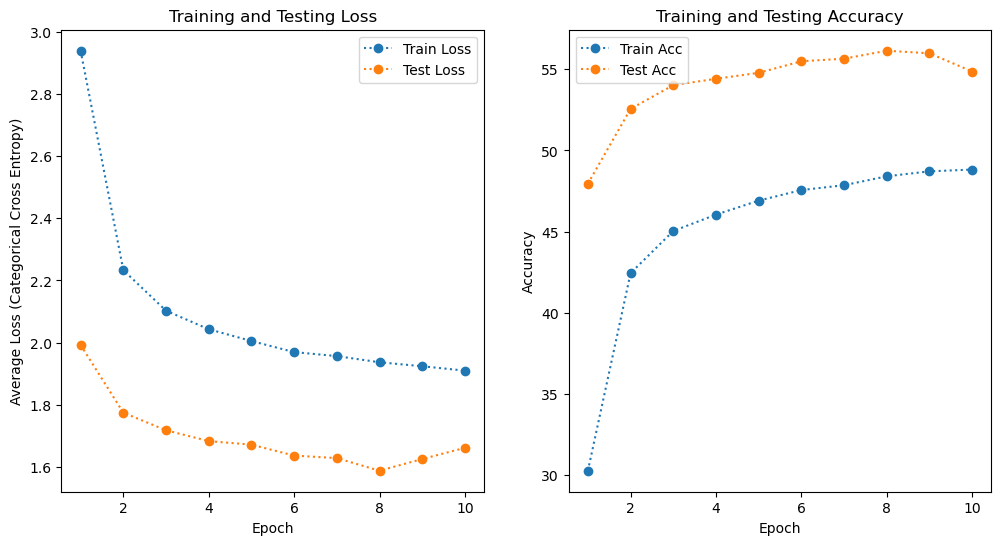

In [15]:
train_and_plot(model, trainloader, testloader, loss, optimizer, num_epochs=10)

# Study Guide

## CNN Fundamentals

**Topics to review:**
- Convolution definition, learned parameters (weights + bias), multi‑channel formula
- Output size formula and what $H, W, K, P, S$ mean
- Feature maps, channels, and why multiple filters are used
- Activation functions (ReLU, Leaky ReLU, GELU) and why nonlinearity matters
- Pooling vs strided convolution (trade‑offs, when to use)
- Receptive field growth with stacked small kernels
- Parameter efficiency of conv layers vs fully connected layers

**Example questions:**
- Given $H=32, K=3, P=1, S=2$, what is $H_{out}$?
- Why do we usually use ReLU instead of sigmoid in CNN feature extractors?
- What changes in the output when you increase stride from 1 to 2?

## Modern CNN Architecture Fundamentals

**Topics to review:**
- VGG: small 3×3 kernels, deeper networks, why this works
- ResNet: residual connections, why they help gradients
- DenseNet: feature reuse via dense connections
- MobileNet: depthwise separable convolutions and efficiency
- How global average pooling differs from flatten + FC
- The role of batch normalization in modern CNNs

**Example questions:**
- What problem do residual connections solve?
- How does DenseNet differ from ResNet in how features are combined?
- Why are depthwise separable convolutions faster/cheaper?

## Transfer Learning

**Topics to review:**
- Feature extractor vs fine‑tuning (frozen vs unfrozen backbone)
- Why ImageNet pretrained weights work on other tasks
- When to use a smaller learning rate for fine‑tuning
- What layers should be replaced for a new dataset
- Typical preprocessing for pretrained models (resize, normalize)

**Example questions:**
- Why does fine‑tuning usually require a smaller learning rate?
- What happens if you forget ImageNet normalization when using pretrained weights?
- Which layers do you replace when adapting ResNet18 to CIFAR‑10?
